<a href="https://colab.research.google.com/github/Kavishka2401/CustomerChurnPredictionSystem/blob/master/Final_NN_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Mount the google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [26]:
# Core libraries
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Scikit-learn libraries
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    f1_score,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    classification_report
)

# Imbalanced-learn library
from imblearn.over_sampling import BorderlineSMOTE

# TensorFlow / Keras libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC, Precision, Recall
from tensorflow.keras.regularizers import l2

# Reproducibility / Seed setup
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'


In [21]:
# Provide path
df = pd.read_csv('/content/drive/MyDrive/processed_data_NN.csv')
# Copy data
churn_data = df.copy()

In [22]:
churn_data.columns

Index(['TotalCharges_numeric', 'tenure', 'MonthlyCharges', 'SeniorCitizen',
       'AvgChargePerMonth', 'Churn', 'Dependents_Yes',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes'],
      dtype='object')

In [23]:
# Show all columns
pd.set_option('display.max_columns', None)

# Show all rows if needed
pd.set_option('display.max_rows', None)

# Prevent truncation of long strings in cells
pd.set_option('display.max_colwidth', None)

churn_data.head()

,TotalCharges_numeric,tenure,MonthlyCharges,SeniorCitizen,AvgChargePerMonth,Churn,Dependents_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes
0,0.072892,0.013889,0.115423,0,0.090838,0,0,0,0,0,1,0,0,0,0,0,0,1
1,0.749358,0.472222,0.385075,0,0.342582,0,0,0,1,0,0,0,1,0,0,1,0,0
2,0.280590,0.027778,0.354229,0,0.262376,1,0,0,1,0,1,0,0,0,0,0,0,1
3,0.745063,0.625000,0.239303,0,0.283037,0,0,0,1,0,0,0,1,0,1,1,0,0
4,0.335724,0.027778,0.521891,0,0.329474,1,0,0,0,0,0,0,0,0,0,0,0,1


In [24]:
# INITIATE X AND Y
X = churn_data.drop(columns=['Churn'])
y = churn_data['Churn']

# Randomly select 10 samples for inference
X_infer = X.sample(n=10, random_state=42)
y_infer = y.loc[X_infer.index]

# Remove inference rows from main dataset
X_rest = X.drop(X_infer.index)
y_rest = y.drop(y_infer.index)

# Split the rest into training+validation and testing sets
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_rest, y_rest,
    test_size=0.2,
    random_state=42,
    stratify=y_rest
)
# Further split training set into actual training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train_full
)

# Check shapes
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("X_infer:", X_infer.shape)

# Check class distribution in original training set
print("Original training set class distribution:")
print(y_train.value_counts())

# Percentages
print("\nOriginal training set class distribution (percentages):")
print(y_train.value_counts(normalize=True) * 100)

X_train: (4500, 17)
X_val: (1126, 17)
X_test: (1407, 17)
X_infer: (10, 17)
Original training set class distribution:
Churn
0    3307
1    1193
Name: count, dtype: int64

Original training set class distribution (percentages):
Churn
0    73.488889
1    26.511111
Name: proportion, dtype: float64


After Borderline-SMOTE class counts:
 Churn
0    3307
1    3307
Name: count, dtype: int64
Class weights: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0)}
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5480 - f1_metric: 0.3572 - loss: 0.7137 - val_accuracy: 0.7389 - val_f1_metric: 0.5665 - val_loss: 0.6128 - learning_rate: 3.0000e-04
Epoch 2/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6376 - f1_metric: 0.6100 - loss: 0.6636 - val_accuracy: 0.7060 - val_f1_metric: 0.5598 - val_loss: 0.5745 - learning_rate: 3.0000e-04
Epoch 3/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6814 - f1_metric: 0.6793 - loss: 0.6282 - val_accuracy: 0.7016 - val_f1_metric: 0.5849 - val_loss: 0.5621 - learning_rate: 3.0000e-04
Epoch 4/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7107 - f1_metric: 0.7234 - loss: 0.6010 - val_accuracy: 0.7043 - val_f1_metric: 0.5918 - val_loss: 0.5548 - learning_rate: 3.0000e-04
Epoch 5/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7186 - f1_metric: 0.7358 - loss: 0.5836 - val_accuracy: 0.7060 - val_f1_metric: 0.6026 - val_loss: 0.5555 - learning_rate: 3.0000e-04
Epoch 6

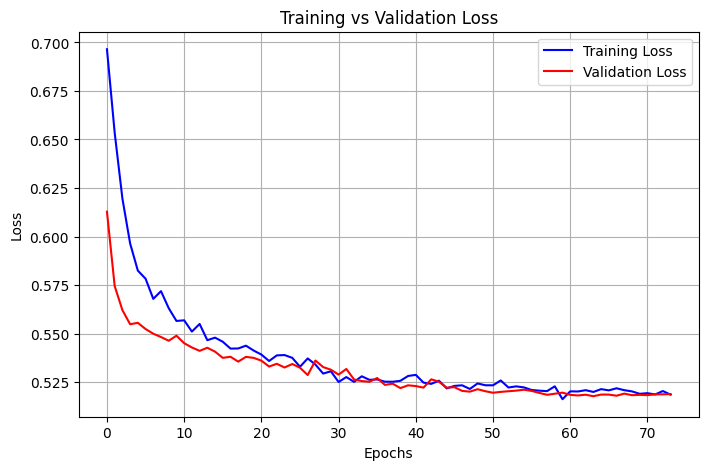

In [27]:
# Apply Borderline-SMOTE on training set only
smote = BorderlineSMOTE(
    sampling_strategy='auto',
    random_state=42,
    kind='borderline-2'
)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("After Borderline-SMOTE class counts:\n", pd.Series(y_train_res).value_counts())

# Compute class weights on resampled training data
classes = np.unique(y_train_res)
class_weights_values = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_res)
class_weight_dict = dict(zip(classes, class_weights_values))
print("Class weights:", class_weight_dict)

# Initialize simplified model
model = Sequential()

# Input layer + first hidden layer
model.add(tf.keras.layers.Dense(
    units=32,
    activation='relu',
    input_shape=(X_train_res.shape[1],),
    kernel_regularizer=l2(0.001)
))
model.add(tf.keras.layers.Dropout(0.3, seed=SEED))

# Second hidden layer
model.add(tf.keras.layers.Dense(
    units=16,
    activation='relu',
    kernel_regularizer=l2(0.001)  # L2 regularization
))
model.add(tf.keras.layers.Dropout(0.3, seed=SEED))

# Output layer
model.add(Dense(units=1, activation='sigmoid'))

# Custom F1 metric
def f1_metric(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.round(y_pred)
    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum((1 - y_true) * y_pred)
    fn = tf.reduce_sum(y_true * (1 - y_pred))
    precision = tp / (tp + fp + tf.keras.backend.epsilon())
    recall = tp / (tp + fn + tf.keras.backend.epsilon())
    return 2 * (precision * recall) / (precision + recall + tf.keras.backend.epsilon())

opt = Adam(learning_rate=0.0003)
# Compile model
model.compile(
    optimizer=opt,
    loss='binary_crossentropy',
    metrics=['accuracy', f1_metric]
)

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# Train model with class weights
history = model.fit(
    X_train_res, y_train_res,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Predict and find best threshold
y_probs = model.predict(X_test).ravel()
thresholds = np.arange(0.1, 0.9, 0.05)
best_t = 0.5
best_f1 = 0

for t in thresholds:
    preds = (y_probs > t).astype(int)
    f1 = f1_score(y_test, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t
print("Best Threshold:", best_t)

# Predictions
y_train_pred = (model.predict(X_train_res) > best_t).astype(int)
y_val_pred = (model.predict(X_val) > best_t).astype(int)
y_test_pred = (model.predict(X_test) > best_t).astype(int)

# Evaluate
acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
rec = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)

# Classification reports
print("Training Set Report")
print(classification_report(y_train_res, y_train_pred))
print("Validation Set Report")
print(classification_report(y_val, y_val_pred))
print("Test Set Report")
print(classification_report(y_test, y_test_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", cm)

# Plot loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], 'b-', label='Training Loss')
plt.plot(history.history['val_loss'], 'r-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [35]:
# Save the entire model
# Define path in your Google Drive
model_path = '/content/drive/MyDrive/NN_model.h5'

# Save the model
model.save(model_path)
print("Model saved to Google Drive at:", model_path)

# Save history
import pickle
with open('/content/drive/MyDrive/NN_model_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

# Save
with open('/content/drive/MyDrive/X_train_res.pkl', 'wb') as f:
    pickle.dump(X_train_res, f)
with open('/content/drive/MyDrive/y_train_res.pkl', 'wb') as f:
    pickle.dump(y_train_res, f)

Model saved to Google Drive at: /content/drive/MyDrive/NN_model.h5


In [3]:
from tensorflow.keras.models import load_model
model_path = '/content/drive/MyDrive/NN_model.h5'

# Load model
model = load_model(model_path, compile=False)

# Load History
with open('/content/drive/MyDrive/history.pkl', 'rb') as f:
    history = pickle.load(f)

# Load later
with open('/content/drive/MyDrive/X_train_res.pkl', 'rb') as f:
    X_train_res = pickle.load(f)
with open('/content/drive/MyDrive/y_train_res.pkl', 'rb') as f:
    y_train_res = pickle.load(f)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Best Threshold: 0.7000000000000002
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

=== TEST METRICS ===
Test Accuracy: 0.7761194029850746
Test Precision: 0.5668202764976958
Test Recall: 0.6595174262734584
Test F1 Score: 0.6096654275092936
Training Set Report
              precision    recall  f1-score   support

           0       0.67      0.83      0.74      3307
           1       0.77      0.59      0.67      3307

    accuracy                           0.71      6614
   macro avg       0.72      0.71      0.70      6614
weighted avg       0.72      0.71      0.70      6614

Validation Set Report
              precision    recall  f1-score   support

           0       0.88      0.82      0.85       828
           1       0.58      0.68      0.63       298

    accuracy                           0.79      1126
   macro avg       0.73 

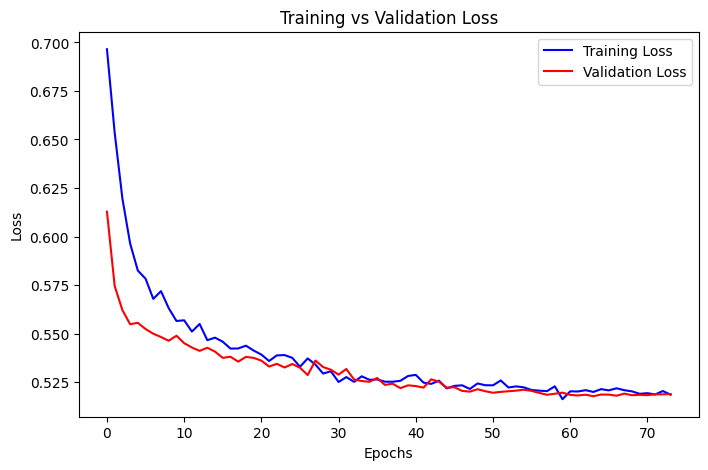

In [34]:
# Predict and find best threshold
y_probs = model.predict(X_test).ravel()
thresholds = np.arange(0.1, 0.9, 0.05)
best_t = 0.5
best_f1 = 0

# Custom F1 metric
def f1_metric(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.round(y_pred)
    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum((1 - y_true) * y_pred)
    fn = tf.reduce_sum(y_true * (1 - y_pred))
    precision = tp / (tp + fp + tf.keras.backend.epsilon())
    recall = tp / (tp + fn + tf.keras.backend.epsilon())
    return 2 * (precision * recall) / (precision + recall + tf.keras.backend.epsilon())

# Use loaded model
y_probs = model.predict(X_test).ravel()
thresholds = np.arange(0.1, 0.9, 0.05)
best_t = 0.5
best_f1 = 0

for t in thresholds:
    preds = (y_probs > t).astype(int)
    f1 = f1_score(y_test, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t
print("Best Threshold:", best_t)

# Predictions
y_train_pred = (model.predict(X_train_res) > best_t).astype(int)
y_val_pred = (model.predict(X_val) > best_t).astype(int)
y_test_pred = (model.predict(X_test) > best_t).astype(int)

# TEST METRICS
print("\n=== TEST METRICS ===")
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test Precision:", precision_score(y_test, y_test_pred))
print("Test Recall:", recall_score(y_test, y_test_pred))
print("Test F1 Score:", f1_score(y_test, y_test_pred))

# Classification reports
print("Training Set Report")
print(classification_report(y_train_res, y_train_pred))
print("Validation Set Report")
print(classification_report(y_val, y_val_pred))
print("Test Set Report")
print(classification_report(y_test, y_test_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", cm)

# Correct access
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], 'b-', label='Training Loss')
plt.plot(history.history['val_loss'], 'r-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [36]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,365 (13.15 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,244 (8.77 KB)

In [31]:
# Randomly select 10 new rows from the full dataset
X_infer = X.sample(n=10, replace=False, random_state=123)
y_infer = y.loc[X_infer.index]

# Reset indices for proper alignment
X_infer = X_infer.reset_index(drop=True)
y_infer = y_infer.reset_index(drop=True)

# Predict probabilities and apply best threshold
y_infer_probs = model.predict(X_infer).ravel()
y_infer_pred = (y_infer_probs > best_t).astype(int)

# Convert actual labels to numeric
y_infer_numeric = y_infer.replace({'Non-Churn':0,'Churn':1})

# Map numeric labels to strings for display
label_map = {0:'Non-Churn', 1:'Churn'}
actual_labels = y_infer_numeric.map(label_map)
pred_labels = pd.Series(y_infer_pred).map(label_map)

# Build inference table
inference_table = X_infer.copy()
inference_table['Actual'] = actual_labels
inference_table['Predicted'] = pred_labels
inference_table['Correct?'] = inference_table['Actual'] == inference_table['Predicted']

# Reorder columns
cols = ['Actual','Predicted','Correct?'] + [c for c in inference_table.columns if c not in ['Actual','Predicted','Correct?']]
inference_table = inference_table[cols]

# Display table
display(inference_table)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step


,Actual,Predicted,Correct?,TotalCharges_numeric,tenure,MonthlyCharges,SeniorCitizen,AvgChargePerMonth,Dependents_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes
0,Non-Churn,Non-Churn,True,0.487014,0.180556,0.118408,0,0.207645,1,0,0,0,1,0,0,0,0,0,0,0
1,Non-Churn,Non-Churn,True,0.607609,0.486111,0.050249,0,0.166765,0,1,0,1,0,1,0,1,0,0,1,0
2,Non-Churn,Non-Churn,True,0.452302,0.250000,0.010945,0,0.107384,1,1,0,1,0,1,0,1,0,0,1,0
3,Non-Churn,Churn,False,0.833925,0.597222,0.568159,0,0.399735,0,0,0,0,0,0,0,0,0,0,0,1
4,Non-Churn,Non-Churn,True,0.648216,0.708333,0.023881,0,0.143423,0,1,0,1,0,1,0,1,0,0,1,0
5,Non-Churn,Non-Churn,True,0.643267,0.736111,0.007960,0,0.130325,0,1,0,1,0,1,0,1,0,1,0,0
6,Non-Churn,Churn,False,0.499224,0.111111,0.270647,0,0.309619,1,0,0,0,0,0,0,0,0,0,0,1
7,Non-Churn,Non-Churn,True,0.916690,0.694444,0.852736,0,0.471223,0,0,1,0,0,0,1,0,0,1,0,1
8,Non-Churn,Non-Churn,True,0.904603,0.611111,0.910945,1,0.481609,0,0,1,0,1,0,1,0,0,1,0,1
9,Non-Churn,Non-Churn,True,0.940038,0.986111,0.668657,0,0.430470,1,0,1,0,1,0,1,0,1,0,1,0


In [33]:
# Reset indices for proper alignment
X_infer_reset = X_infer.reset_index(drop=True)
y_infer_reset = y_infer.reset_index(drop=True)

# Predict probabilities and apply best threshold
y_infer_probs = model.predict(X_infer_reset).ravel()
y_infer_pred = (y_infer_probs > best_t).astype(int)

# Convert actual labels to numeric 0/1 if needed
y_infer_numeric = y_infer_reset.replace({'Non-Churn':0,'Churn':1})

# Map numeric labels to strings for display
label_map = {0:'Non-Churn', 1:'Churn'}
actual_labels = y_infer_numeric.map(label_map)
pred_labels = pd.Series(y_infer_pred).map(label_map)

# Build inference table
inference_table = X_infer_reset.copy()
inference_table['Actual'] = actual_labels
inference_table['Predicted'] = pred_labels
inference_table['Correct?'] = inference_table['Actual'] == inference_table['Predicted']

# Reorder columns
cols = ['Actual','Predicted','Correct?'] + [c for c in inference_table.columns if c not in ['Actual','Predicted','Correct?']]
inference_table = inference_table[cols]

# Display table
display(inference_table)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step


,Actual,Predicted,Correct?,TotalCharges_numeric,tenure,MonthlyCharges,SeniorCitizen,AvgChargePerMonth,Dependents_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes
0,Non-Churn,Non-Churn,True,0.487014,0.180556,0.118408,0,0.207645,1,0,0,0,1,0,0,0,0,0,0,0
1,Non-Churn,Non-Churn,True,0.607609,0.486111,0.050249,0,0.166765,0,1,0,1,0,1,0,1,0,0,1,0
2,Non-Churn,Non-Churn,True,0.452302,0.250000,0.010945,0,0.107384,1,1,0,1,0,1,0,1,0,0,1,0
3,Non-Churn,Churn,False,0.833925,0.597222,0.568159,0,0.399735,0,0,0,0,0,0,0,0,0,0,0,1
4,Non-Churn,Non-Churn,True,0.648216,0.708333,0.023881,0,0.143423,0,1,0,1,0,1,0,1,0,0,1,0
5,Non-Churn,Non-Churn,True,0.643267,0.736111,0.007960,0,0.130325,0,1,0,1,0,1,0,1,0,1,0,0
6,Non-Churn,Churn,False,0.499224,0.111111,0.270647,0,0.309619,1,0,0,0,0,0,0,0,0,0,0,1
7,Non-Churn,Non-Churn,True,0.916690,0.694444,0.852736,0,0.471223,0,0,1,0,0,0,1,0,0,1,0,1
8,Non-Churn,Non-Churn,True,0.904603,0.611111,0.910945,1,0.481609,0,0,1,0,1,0,1,0,0,1,0,1
9,Non-Churn,Non-Churn,True,0.940038,0.986111,0.668657,0,0.430470,1,0,1,0,1,0,1,0,1,0,1,0


Final Advanced Model – Summary

Test Metrics

    Accuracy: 0.7761

    Precision: 0.5668

    Recall: 0.6595

    F1 Score : 0.6096

Training Set Report
| Class            | Precision | Recall | F1-Score | Support |
| ---------------- | --------- | ------ | -------- | ------- |
| 0                | 0.67      | 0.83   | 0.74     | 3307    |
| 1                | 0.77      | 0.59   | 0.67     | 3307    |
| **Accuracy**     |           |        | 0.71     | 6614    |
| **Macro Avg**    | 0.72      | 0.71   | 0.70     | 6614    |
| **Weighted Avg** | 0.72      | 0.71   | 0.70     | 6614    |


Validation Set Report
| Class            | Precision | Recall | F1-Score | Support |
| ---------------- | --------- | ------ | -------- | ------- |
| 0                | 0.88      | 0.82   | 0.85     | 828     |
| 1                | 0.58      | 0.68   | 0.63     | 298     |
| **Accuracy**     |           |        | 0.79     | 1126    |
| **Macro Avg**    | 0.73      | 0.75   | 0.74     | 1126    |
| **Weighted Avg** | 0.80      | 0.79   | 0.79     | 1126    |

Test Set Report
| Class            | Precision | Recall | F1-Score | Support |
| ---------------- | --------- | ------ | -------- | ------- |
| 0                | 0.87      | 0.82   | 0.84     | 1034    |
| 1                | 0.57      | 0.66   | 0.61     | 373     |
| **Accuracy**     |           |        | 0.78     | 1407    |
| **Macro Avg**    | 0.72      | 0.74   | 0.73     | 1407    |
| **Weighted Avg** | 0.79      | 0.78   | 0.78     | 1407    |


Confusion Matrix (Test)
|              | Pred 0 | Pred 1 |
| ------------ | ------ | ------ |
| **Actual 0** | 846    | 188    |
| **Actual 1** | 127    | 246    |